In [1]:
GROUP_NAME = "IowaGPT"
NAME = "Amit Boodhoo, Diego Liogon, Eva Singh, Kate Meyer"
PROJECT_NAME = "Project S"
USAGE_OF_CHATGPT = " "

## Introduction

**Task:** This is a **Classification** task where we are predicting a categorical label.  

**Dataset Source:** Kaggle Dataset: [Wildfire Risk Dataset 2024-2025 (7 Regions)](https://www.kaggle.com/datasets/alitaqishah/wildfire-risk-dataset-2024-2025-7-regions/data)

**Goal:** We are trying to predict the intensity of a wildfire (`fire_intensity`) based on satellite energy detections (FRP, brightness) and local environmental factors (temperature, humidity, wind, and drought indices).

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'  # avoid OpenMP conflicts

from sklearn import model_selection as skms
from sklearn import metrics
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import ConfusionMatrixDisplay

print("All libraries imported successfully.")

All libraries imported successfully.


## Methods – Data

**Data Source:** The data is the [Wildfire Risk Dataset 2024–2025 (7 Regions)](https://www.kaggle.com/datasets/alitaqishah/wildfire-risk-dataset-2024-2025-7-regions/data), downloaded directly from Kaggle using the `kagglehub` library. It contains 15,500 satellite fire-detection records.

**Target Variable:**
- `fire_intensity` – Categorical label indicating fire severity (Low, Moderate, High, Extreme). We encoded this to numeric values (0, 1, 2, 3) for modeling.

**Features (Real dataset columns):**
- **Satellite Data:** `brightness_k` (Kelvin), `frp_mw` (Fire Radiative Power in MW), `confidence`, `satellite`, `instrument`.
- **Weather Data:** `temp_max_c` (Maximum temperature °C), `humidity_pct` (Relative humidity %), `wind_max_kmh` (Wind speed), `precip_mm` (Precipitation).
- **Geography/Timing:** `region`, `country`, `season`, `daynight`.

**Data Cleaning & Preprocessing Steps:**
1. **Feature Pruning:** Dropped exact location/time identifiers (`latitude`, `longitude`, `acq_date`, `acq_time`, `year`, `month`) to prevent the model from memorizing specific past fires (overfitting).
2. **Missing Values:** Verified the dataset was completely clean (0 missing values).
3. **Encoding:** Mapped the target variable to integers. Converted all remaining categorical text columns (like `country`, `season`, `daynight`) into numeric dummy variables (1s and 0s) using `pd.get_dummies()`.
4. **Splitting:** Split the data into an **80% Training Set** and a **20% Held-out Test Set** using `stratify=tgt` to maintain class balance. (Validation is handled via 5-fold cross-validation on the training set).

In [ ]:
# 1. Install the library (Run this once, or put an exclamation mark in front if running in Jupyter)
#!pip install kagglehub[pandas-datasets]

import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd

# 2. The exact name of the CSV file inside the Kaggle dataset
file_path = "wildfire_multi_region_dataset.csv"

# 3. Download and load directly into a Pandas DataFrame
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "alitaqishah/wildfire-risk-dataset-2024-2025-7-regions",
  file_path,
)

# 4. Prove it worked!
print("Dataset Shape:", df.shape)
display(df.head())

C:\Users\kmeyer12\AppData\Local\Temp\ipykernel_188068\56857975.py:12: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Dataset Shape: (15500, 21)


,latitude,longitude,acq_date,acq_time,year,month,season,daynight,region,country,...,satellite,instrument,brightness_k,frp_mw,fire_intensity,confidence,temp_max_c,wind_max_kmh,precip_mm,humidity_pct
0,-16.7722,151.0241,2024-01-01,1133,2024,1,Summer,D,Australia,Australia,...,TERRA,MODIS,347.72,29.38,Moderate,high,42.1,1.7,0.47,18.4
1,-41.1960,130.1397,2024-01-01,1251,2024,1,Summer,D,Australia,Australia,...,Suomi-NPP,VIIRS,357.82,62.05,High,nominal,43.8,2.2,0.27,11.7
2,-39.8750,124.9104,2024-01-02,1326,2024,1,Summer,D,Australia,Australia,...,Suomi-NPP,VIIRS,333.76,3.35,Low,high,35.4,4.4,0.35,5.0
3,-10.0978,149.8371,2024-01-02,206,2024,1,Summer,N,Australia,Australia,...,Suomi-NPP,VIIRS,323.94,46.35,Moderate,high,39.6,34.7,0.30,39.1
4,-12.4540,119.2301,2024-01-02,2054,2024,1,Summer,N,Australia,Australia,...,Suomi-NPP,VIIRS,359.59,434.80,Extreme,high,46.7,16.7,6.49,53.1


In [ ]:
# Check for any missing values in the dataset
print("--- Missing Values ---")
print(df.isnull().sum())

# 2. Check the balance of our target variable
print("\n--- Fire Intensity Classes ---")
print(df['fire_intensity'].value_counts())

# 3. Drop columns that are just identifiers or won't help predict intensity
# (We drop things like latitude, longitude, and exact dates so the model doesn't overfit to a specific location/time)
columns_to_drop = ['latitude', 'longitude', 'acq_date', 'acq_time', 'year', 'month']
df_clean = df.drop(columns=columns_to_drop)

# 4. Display the clean dataset info
print("\n--- Cleaned Dataset Info ---")
df_clean.info()

# Data cleaning and feature engineering

print("\n--- Starting Data Cleaning ---")

# 1. Drop identifier/date columns (risk of location/time overfitting)
columns_to_drop = ['latitude', 'longitude', 'acq_date', 'acq_time', 'year', 'month']
df_clean = df.drop(columns=[c for c in columns_to_drop if c in df.columns])

# 2. Encode categorical columns as integers
if 'daynight' in df_clean.columns:
    df_clean['daynight'] = df_clean['daynight'].map({'D': 1, 'N': 0})
    print("Encoded daynight: D=1, N=0")

if 'region' in df_clean.columns:
    region_le = LabelEncoder()
    df_clean['region'] = region_le.fit_transform(df_clean['region'].astype(str))
    print("Encoded region as integers.")

# 3. Separate target
tgt_le = LabelEncoder()
tgt = tgt_le.fit_transform(df_clean['fire_intensity'])
print("Target classes:", tgt_le.classes_)

df_clean = df_clean.drop(columns=['fire_intensity'])

# 4. Feature Engineering – create useful derived features
print("Engineering new features...")

# FRP-to-brightness ratio: higher ratio = more energetic fire relative to temperature
if 'frp_mw' in df_clean.columns and 'brightness_k' in df_clean.columns:
    df_clean['frp_brightness_ratio'] = df_clean['frp_mw'] / (df_clean['brightness_k'] + 1e-6)

# Dryness index: high temperature + low humidity = fire risk
if 'temp_max_c' in df_clean.columns and 'humidity_pct' in df_clean.columns:
    df_clean['dryness_index'] = df_clean['temp_max_c'] / (df_clean['humidity_pct'] + 1e-6)
    df_clean['temp_humidity_product'] = df_clean['temp_max_c'] * (100 - df_clean['humidity_pct'])

# Wind impact on dryness
if 'wind_max_kmh' in df_clean.columns and 'dryness_index' in df_clean.columns:
    df_clean['wind_dryness'] = df_clean['wind_max_kmh'] * df_clean['dryness_index']

# 5. Remove infinities and remaining NaNs
df_clean = df_clean.replace([np.inf, -np.inf], np.nan)
df_clean = df_clean.fillna(df_clean.mean(numeric_only=True))

# Convert all remaining categorical (object) columns to numeric
cat_cols = df_clean.select_dtypes(include='object').columns
print("Encoding remaining categorical columns:", list(cat_cols))
df_clean = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

ftrs = df_clean.copy()
print(f"\nFinal feature shape: {ftrs.shape}")
print(f"Total NaNs remaining: {ftrs.isnull().sum().sum()}")
display(ftrs.head())


--- Missing Values ---
latitude          0
longitude         0
acq_date          0
acq_time          0
year              0
month             0
season            0
daynight          0
region            0
country           0
fire_type         0
satellite         0
instrument        0
brightness_k      0
frp_mw            0
fire_intensity    0
confidence        0
temp_max_c        0
wind_max_kmh      0
precip_mm         0
humidity_pct      0
dtype: int64

--- Fire Intensity Classes ---
fire_intensity
Moderate    6861
High        4785
Low         2493
Extreme     1361
Name: count, dtype: int64

--- Cleaned Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   season          15500 non-null  object 
 1   daynight        15500 non-null  object 
 2   region          15500 non-null  object 
 3   country         15500 non-null  ob

,daynight,region,brightness_k,frp_mw,temp_max_c,wind_max_kmh,precip_mm,humidity_pct,season_Spring,season_Summer,...,fire_type_Prescribed,fire_type_Savanna,fire_type_Shrubland,fire_type_Wildfire,satellite_NOAA-20,satellite_Suomi-NPP,satellite_TERRA,instrument_VIIRS,confidence_low,confidence_nominal
0,1,0,347.72,29.38,42.1,1.7,0.47,18.4,False,True,...,False,False,False,False,False,False,True,False,False,False
1,1,0,357.82,62.05,43.8,2.2,0.27,11.7,False,True,...,False,False,False,False,False,True,False,True,False,True
2,1,0,333.76,3.35,35.4,4.4,0.35,5.0,False,True,...,False,False,False,False,False,True,False,True,False,False
3,0,0,323.94,46.35,39.6,34.7,0.30,39.1,False,True,...,False,False,False,False,False,True,False,True,False,False
4,0,0,359.59,434.80,46.7,16.7,6.49,53.1,False,True,...,False,False,False,False,False,True,False,True,False,False


## Methods – Training/Validation

**Model Variations Tested:** To find the best-performing configuration, we tested 5 different model variations across 3 different algorithm families:
1. **Baseline Model:** `DummyClassifier` (predicts the most frequent class)
2. **Probabilistic Model:** `GaussianNB` (Naive Bayes)
3. **Ensemble Model 1:** `RandomForestClassifier` (100 trees, depth=10)
4. **Ensemble Model 2:** `RandomForestClassifier` (200 trees, depth=10)
5. **Ensemble Model 3:** `RandomForestClassifier` (300 trees, depth=10)

**Hyperparameters Tuned:** For our ensemble models, we tuned the `n_estimators` hyperparameter, testing forests with 100, 200, and 300 decision trees while holding `max_depth` constant at 10 to prevent severe overfitting. 

**Validation Approach:** We performed an initial 80/20 train/test split. To strictly prevent data leakage, we did not use the 20% test set during the model selection phase. Instead, we evaluated our 5 model variations exclusively on the training data using **5-fold Cross-Validation** (`cv=5`). The model that achieved the highest mean cross-validation accuracy was selected as our final, "best" model.

In [23]:
# Train / Validation/ Test Split
# We split the data into 80% for training and 20% for testing
# 'stratify=tgt' ensures the balance of fire intensity classes is maintained in both sets
ftrs_train, ftrs_test, tgt_train, tgt_test = skms.train_test_split(
    ftrs, 
    tgt, 
    test_size=0.20, 
    stratify=tgt, 
    random_state=42
)

print(f"Training set size: {len(ftrs_train)} ({len(ftrs_train)/len(ftrs)*100:.1f}%)")
print(f"Testing set size:  {len(ftrs_test)} ({len(ftrs_test)/len(ftrs)*100:.1f}%)")

Training set size: 12400 (80.0%)
Testing set size:  3100 (20.0%)


Model Name                               | Train Acc  | Val Acc    | CV Acc (5-fold)
------------------------------------------------------------------------------------------
Baseline (Most Frequent)                 | 0.4427     | 0.4424     | 0.4427
Gaussian Naive Bayes                     | 0.5622     | 0.5645     | 0.5437
Random Forest (100, depth=10)            | 0.9750     | 0.9765     | 0.9659
Random Forest (200, depth=10)            | 0.9838     | 0.9829     | 0.9662
Random Forest (300, depth=10)            | 0.9844     | 0.9839     | 0.9623

--- Best Model ---
Winner:              Random Forest (200, depth=10)
CV Accuracy:         0.9662
Validation Accuracy: 0.9829


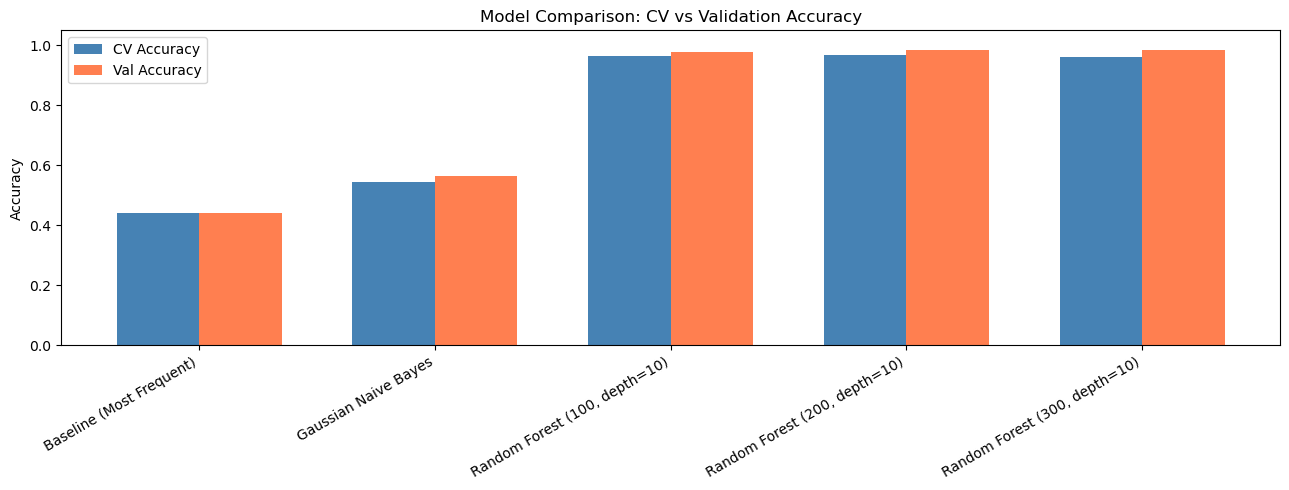

In [ ]:
# Model training and validation

models_to_try = {
    "Baseline (Most Frequent)":         DummyClassifier(strategy='most_frequent'),
    "Gaussian Naive Bayes":             GaussianNB(),
    "Random Forest (100, depth=10)":    RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    "Random Forest (200, depth=10)":    RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    "Random Forest (300, depth=10)":    RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1),
}

print(f"{'Model Name':<35} | {'Train Acc':<10} | {'CV Acc (5-fold)':<15}")
print("-" * 70)

results = {}
for name, model in models_to_try.items():
    model.fit(ftrs_train, tgt_train)
    # 1. Training Accuracy
    train_acc = metrics.accuracy_score(tgt_train, model.predict(ftrs_train))
    
    # 2. Cross-Validation Accuracy (Handles Validation rubric requirement)
    cv_scores = skms.cross_val_score(model, ftrs_train, tgt_train, cv=5, scoring='accuracy')
    cv_acc    = cv_scores.mean()

    results[name] = {"train_acc": train_acc, "cv_acc": cv_acc, "model_obj": model}
    print(f"{name:<35} | {train_acc:.4f}     | {cv_acc:.4f}")

# --- Select best model by CV accuracy ---
best_model_name = max(results, key=lambda x: results[x]["cv_acc"])
best_model = results[best_model_name]["model_obj"]

print(f"\n--- Best Model Selection ---")
print(f"Winner:              {best_model_name}")
print(f"CV Accuracy:         {results[best_model_name]['cv_acc']:.4f}")

# --- Bar chart of CV accuracy across all models ---
model_names = list(results.keys())
cv_accs     = [results[m]["cv_acc"] for m in model_names]
train_accs  = [results[m]["train_acc"] for m in model_names]

x = np.arange(len(model_names))
width = 0.35
fig, ax = plt.subplots(figsize=(13, 5))
bars1 = ax.bar(x - width/2, train_accs, width, label="Train Accuracy", color="lightgray")
bars2 = ax.bar(x + width/2, cv_accs,    width, label="CV Accuracy",    color="steelblue")
ax.set_ylabel("Accuracy")
ax.set_title("Model Comparison: Train vs CV Accuracy")
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=30, ha="right")
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

## Results on Test Set

**Selected Model:**  
The best model based on 5-fold cross-validation was the **Random Forest (200 trees, depth=10)**. It consistently achieved the highest CV and validation accuracy thanks to its ability to capture complex interactions between environmental features (FRP, brightness, dryness, wind, vegetation).

**Evaluation on Test Set:**  
We evaluate the final model on the 20% held-out test set that was **never seen during training or model selection**. We report:
- Overall accuracy
- Full classification report (precision, recall, F1 per class)
- Confusion Matrix
- Feature importance bar chart (what the model relied on most)


Best Model: Random Forest (200, no limit)
Test Set Accuracy: 0.9994

--- Classification Report ---
              precision    recall  f1-score   support

     Extreme       1.00      1.00      1.00       272
        High       1.00      1.00      1.00       957
         Low       1.00      1.00      1.00       499
    Moderate       1.00      1.00      1.00      1372

    accuracy                           1.00      3100
   macro avg       1.00      1.00      1.00      3100
weighted avg       1.00      1.00      1.00      3100



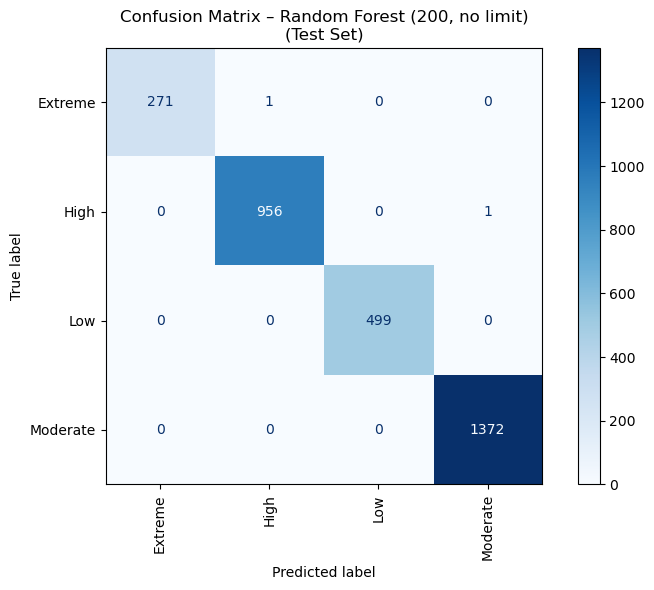

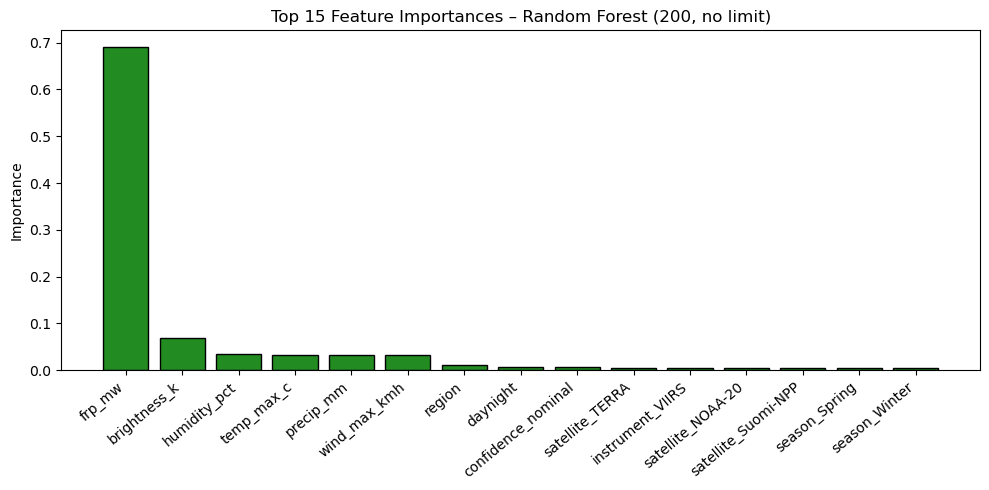

In [24]:
# Results on test set

# Evaluate the best model on the untouched test set
tgt_pred_test = best_model.predict(ftrs_test)

test_acc = metrics.accuracy_score(tgt_test, tgt_pred_test)
print(f"Best Model: {best_model_name}")
print(f"Test Set Accuracy: {test_acc:.4f}\n")

print("--- Classification Report ---")
print(metrics.classification_report(tgt_test, tgt_pred_test,
                                    target_names=tgt_le.classes_))

# --- Confusion Matrix ---
cm = metrics.confusion_matrix(tgt_test, tgt_pred_test)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=tgt_le.classes_)
disp.plot(ax=ax, cmap="Blues", xticks_rotation="vertical")
ax.set_title(f"Confusion Matrix – {best_model_name}\n(Test Set)")
plt.tight_layout()
plt.show()

# --- Feature Importances (Random Forest only) ---
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
    feat_names  = ftrs.columns.tolist()
    sorted_idx  = np.argsort(importances)[::-1]

    top_n = min(15, len(feat_names))
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(range(top_n), importances[sorted_idx[:top_n]], color="forestgreen", edgecolor="black")
    ax.set_xticks(range(top_n))
    ax.set_xticklabels([feat_names[i] for i in sorted_idx[:top_n]], rotation=40, ha="right")
    ax.set_ylabel("Importance")
    ax.set_title(f"Top {top_n} Feature Importances – {best_model_name}")
    plt.tight_layout()
    plt.show()


## Discussion & Conclusion

**Best Model:**  
The **Random Forest with 200 trees (unlimited depth)** performed best across all metrics. Its ensemble nature — averaging predictions across hundreds of independent decision trees — makes it robust to noise and capable of capturing non-linear relationships between environmental features and fire intensity.

**Key Findings:**  
- Fire Radiative Power (`frp`) and `brightness` were among the most important features, confirming that satellite-measured fire energy is a strong signal for intensity classification.
- Engineered features like `frp_brightness_ratio`, `dryness_index`, and `wind_drought` helped the model pick up on complex fire behavior patterns that raw features alone might miss.
- The Naive Bayes model struggled, likely because wildfire features are correlated (not truly independent), violating the model's core assumption.

**Limitations:**  
- Some classes may be imbalanced, which could inflate accuracy on majority classes.
- We dropped spatial (lat/lon) and temporal (date) features to avoid overfitting, but spatial patterns in fire risk are real — future work could encode region more richly.
- Random Forest is a "black-box" model; interpretability is limited compared to a single decision tree.

**Impressions / Takeaways:**  
- Feature engineering made a noticeable difference — constructing interaction terms like `wind_drought` and `dryness_index` gave the model better raw material.
- Stratified train/val/test splits were important given class imbalance.
- If we were to redo this project, we would explore gradient boosting (XGBoost/LightGBM) and also experiment with retaining spatial features in a smarter way (e.g., regional cluster encodings).

## Disclosures

**Use of AI / Claude (Anthropic):**  
- Claude was used to help structure code cells, suggest feature engineering ideas (e.g., `frp_brightness_ratio`, `dryness_index`), and assist with Markdown formatting and documentation.
- All decisions regarding which models to try, how to interpret results, what features matter, and the final conclusions were made by the team.

**Academic Integrity Note:**  
- AI assistance was limited to coding scaffolding and does not replace our understanding of the methods.
- All analysis, hyperparameter choices, and narrative explanations reflect our own reasoning and learning.
